# Необходимые библиотекы для работы 

In [1]:
# базовые библиотеки, модули
import pandas as pd
import numpy as np

#визуализация
import matplotlib.pyplot as plt
import seaborn as sns

#обработка/нормализация
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import StandardScaler

# Загрузка данных

In [2]:
# обучающая выборка
train_df = pd.read_csv("I'll come back later data/train.csv")

In [3]:
# тестовая выборка
test_df = pd.read_csv("I'll come back later data/test.csv")

# EDA

## Сбор первичной информации о датасете (начало предобработки)

In [4]:
# класс - ускоритель для сбора первичной информации о датасете
class DatasetReview:    
    def __init__(self,dataframe):
        self.df = dataframe
        
        self.binary_feats =[
            col for col in self.df.columns
            if self.df[col].nunique(dropna=True) == 2
        ]
        
        self.categorical_feats = [
            col for col in self.df.columns
            if (col not in self.binary_feats) and (not is_numeric_dtype(self.df[col]))
        ]
        
        self.numeric_feats = [
            col for col in self.df.columns
            if (col not in self.binary_feats) and (is_numeric_dtype(self.df[col]))
        ]
        
    def collect_min_info(self):
        print("-" * 10 + "Первые 10 строк датасета" + "-" * 10 + "\n")
        display(self.df.head(10))
        print("\n"+"-" * 10 + "Общие сведения" + "-" * 10 + "\n")
        #определяем признаки
        df_info = pd.DataFrame({
            "Columns":self.df.columns,
            "Тип": self.df.dtypes.values,
            "Уникальные значения":self.df.nunique().values,
            "Заполненные значения (кол-во) ":self.df.count().values,
            "Пропущенные значения (кол-во) ":self.df.isnull().sum().values,
            "Пропущенные значения (проценты) ": (self.df.isnull().sum().values / len(self.df) * 100).round(2),
        })
        with pd.option_context('display.expand_frame_repr', False):
             display(df_info)
        print(f"{self.df.shape} - количество строк/столбцов")
        
        feats_to_describe = {
                             "(Числовые признаки)" : self.numeric_feats,
                             "(Бинарные признаки)" : self.binary_feats,
                             "(Категориальные признаки)" : self.categorical_feats
                            }
        
        for key,feats in feats_to_describe.items():
            if feats:
                print("\n"+"-" * 10 + "Оценка значений " + f"{key}" + "-" * 10 + "\n")
                display(round(self.df[feats].describe(),2))
            else:
                print("\n" + "В тренировочной выборке отсутствуют признаки: " + f"{key}")

        print("\n"+"-" * 10 + "columns" + "-" * 10 + "\n")
        columns = self.df.columns.to_list()
        print(f"ОБЩИЙ СПИСОК ПРИЗНАКОВ:{columns}")

    def get_null(self) -> pd.DataFrame:
        df_nulls = self.df[self.df.isnull().any(axis=1)]
        colours = ["black","yellow"]
        sns.heatmap(self.df.isnull(),cmap=sns.color_palette(colours))
        plt.show()
        return df_nulls

    def get_duplicates(self,cols:list = None,keep="first") -> pd.DataFrame:
        duplicates_mask = self.df.duplicated(keep=keep,subset=cols)
        duplicated_df = self.df[duplicates_mask]
        return duplicated_df

## Визуализация/Обработка выбросов

In [19]:
def make_plots_for_ejections(dataframe,feature,bins="auto",is_bool=False,is_cat=False):
    #удобная тема для анализа распределния и выбросов
    sns.set_theme(style="darkgrid")
    # Отображение категориальных признаков
    if is_cat:
        if dataframe[feature].nunique() <= 15:
            display(dataframe[feature].value_counts())
            sns.countplot(data=dataframe,y=feature)
            plt.title(f"Распределение категориального признака {feature}")
            plt.show()
        else:
            display(dataframe[feature].value_counts())
            return "Слишком много категориальных признаков для отображения"
            

        #добавим статистику
        cat_stats = dataframe[feature]
        return

    
    #отображение булевых признаков
    if is_bool:
        display(dataframe[feature].value_counts())
        sns.countplot(data=dataframe, x=feature)
        plt.title(f"Распределение бинарного признака {feature}")
        plt.show()
        return


    # По дефолту функция принимает числовые признаки. Отображение числовых признаков
    # Создаем сетку
    plt.figure(figsize=(15,6))

    #1 Подграфик
    plt.subplot(1,3,1)
    sns.histplot(
        data = dataframe,
        x = feature,
        bins = bins,
        kde=True
    )
    plt.title("Распределение признака " + f"{feature}")
    plt.xlabel(f"{feature}")
    plt.ylabel("Количество наблюдений")

    #добавим IQR для наглядности
    threshold = 1.5
    Q1 = dataframe[feature].quantile(0.25)
    Q3 = dataframe[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - IQR * threshold
    upper_bound = Q3 + IQR * threshold
    ejections = dataframe[(dataframe[feature] < lower_bound) | (dataframe[feature] > upper_bound)].sort_values(feature,ascending = False)
    
    plt.axvline(Q1,color = "green",ls = "--", label="Q1 / Q3 (IQR)"), plt.axvline(Q3,color = "green",ls="--")
    plt.axvline(lower_bound,color = "red", ls = "--",label="Upper/Lower bound"), plt.axvline(upper_bound,color = "red", ls = "--")
    
    #добавим небольшой отступ для удобной интерпретации
    margin = (dataframe[feature].max() - dataframe[feature].min()) * 0.05
    plt.xlim(dataframe[feature].min() - margin,dataframe[feature].max() + margin)

    plt.legend(loc='upper right', fontsize=9)
    plt.tight_layout()

    #2 подграфик
    plt.subplot(1,3,2)
    sns.boxplot(data=dataframe,
                x=feature,
                color="lightblue",
                showmeans = True,
                meanprops={"marker":"o", "markerfacecolor":"blue"}
)
    plt.title(f"Boxplot для {feature}")
    plt.xlim(dataframe[feature].min() - margin,dataframe[feature].max() + margin)
    
    plt.show()
    return ejections

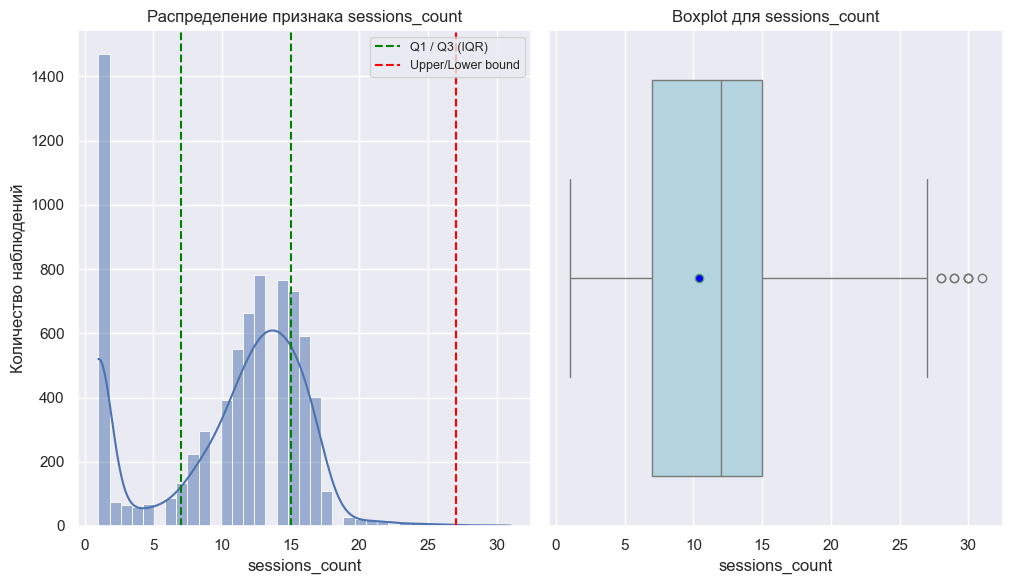

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
1441,1488,31,51.218663,22,14,7382.701290,19,13.029392,1,1
1475,2196,30,43.912519,23,9,6811.676555,19,12.236026,1,1
5602,3171,30,47.764929,10,12,8042.336747,23,7.639139,0,1
4954,1872,30,23.731409,17,12,4231.308273,15,11.218656,1,1
6918,9283,29,38.957243,8,13,5133.488931,17,10.859650,0,1
3417,3689,29,48.321277,20,10,6564.141370,16,14.662543,0,0
4666,6845,28,32.373726,37,11,4733.130145,16,13.806855,1,0
5531,3444,28,32.745981,18,12,4961.841245,17,16.019503,1,0


In [20]:
# Пример работы метода
f = make_plots_for_ejections(dataframe=train_df,feature="sessions_count")
display(f)

In [21]:
# Создадим Preprocession Pipeline для быстрого взгляда на данные с дальнейшей обработкой выбросов,дубликатов и пустых значений
class DataPreprocessingPipeline:
    def __init__(self,dataframe):
        self.df = dataframe
        self.reviewer = None
        self.df_duplicates = None
        self.df_nulls = None
        self.num_feats = None
        self.cat_feats = None
        self.bin_feats = None
        
        
    def start_pipeline(self):
        print("\n === ЭТАП 1: Первичная разведка === \n")
        
        self.reviewer = DatasetReview(self.df)
        self.reviewer.collect_min_info()

        print("\n --- Проверка на Null/NaN --- ")
        self.df_nulls = self.reviewer.get_null()
        display(self.df_nulls)

        print("\n --- Проверка на Duplicates --- ")
        self.df_duplicates = self.reviewer.get_duplicates() #можно вызывать для отдельных колонок
        display(self.df_duplicates)
        
        print("\n === ЭТАП 2: Визуализация выбросов === ")
        self.num_feats = self.reviewer.numeric_feats
        self.cat_feats = self.reviewer.categorical_feats
        self.bin_feats = self.reviewer.binary_feats

        print("\n --- Визуализация выбросов (Числовые признаки) --- ")
        for feat in self.num_feats:
            ejections_df = make_plots_for_ejections(dataframe=self.df,feature=feat,bins="auto")
            display(ejections_df)

        print("\n --- Визуализация выбросов (Категориальные признаки) --- ")
        for feat in self.cat_feats:
            ejections_df = make_plots_for_ejections(dataframe=self.df,feature=feat,bins="auto",is_cat=True)
            display(ejections_df)

        print("\n --- Визуализация (Бинарные признаки) --- ")
        for feat in self.bin_feats:
            make_plots_for_ejections(dataframe=self.df,feature=feat,bins=2,is_bool=True)
        


 === ЭТАП 1: Первичная разведка === 

----------Первые 10 строк датасета----------



,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
0,1045,16,46.079173,9,13,5462.010418,18,14.307116,1,0
1,1339,1,42.625268,24,8,4679.746955,14,26.690708,1,1
2,5144,16,67.310472,21,12,6532.157783,21,13.092315,1,1
3,7099,16,78.904027,34,14,7155.049697,28,10.564979,0,0
4,7907,8,50.456513,19,12,6214.569079,25,6.813272,1,0
5,8270,8,53.347437,13,15,5488.464653,24,14.155992,0,1
6,7561,13,61.133285,33,13,6048.712739,19,12.939032,0,1
7,7178,1,46.142219,5,10,4391.536260,19,20.047936,0,0
8,1164,12,56.564963,10,14,5862.348197,20,13.027084,0,0
9,6735,1,42.455049,24,8,4365.236948,15,13.502038,0,0



----------Общие сведения----------



,Columns,Тип,Уникальные значения,Заполненные значения (кол-во),Пропущенные значения (кол-во),Пропущенные значения (проценты)
0,id,int64,7595,7595,0,0.0
1,sessions_count,int64,31,7595,0,0.0
2,avg_session_time,float64,7588,7595,0,0.0
3,days_since_last_activity,int64,55,7595,0,0.0
4,purchases_count,int64,19,7595,0,0.0
5,avg_purchase_value,float64,7444,7595,0,0.0
6,active_days,int64,23,7595,0,0.0
7,session_std,float64,7574,7595,0,0.0
8,is_weekend_user,int64,2,7595,0,0.0
9,retention,int64,2,7595,0,0.0


(7595, 10) - количество строк/столбцов

----------Оценка значений (Числовые признаки)----------



,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std
count,7595.00,7595.00,7595.00,7595.00,7595.00,7595.00,7595.00,7595.00
mean,5042.75,10.43,56.82,19.57,12.15,5870.97,20.23,11.91
std,2937.71,5.64,12.01,9.33,2.44,1429.78,4.14,3.76
min,1.00,1.00,23.73,0.00,3.00,2097.95,8.00,0.00
25%,2461.50,7.00,47.16,13.00,11.00,4780.69,17.00,9.50
50%,5042.00,12.00,54.47,20.00,12.00,5542.28,20.00,11.79
75%,7580.50,15.00,66.07,26.00,14.00,6880.58,22.00,14.21
max,10127.00,31.00,90.00,55.00,21.00,10000.00,30.00,30.66



----------Оценка значений (Бинарные признаки)----------



,is_weekend_user,retention
count,7595.0,7595.00
mean,0.5,0.73
std,0.5,0.44
min,0.0,0.00
25%,0.0,0.00
50%,0.0,1.00
75%,1.0,1.00
max,1.0,1.00



В тренировочной выборке отсутствуют признаки: (Категориальные признаки)

----------columns----------

ОБЩИЙ СПИСОК ПРИЗНАКОВ:['id', 'sessions_count', 'avg_session_time', 'days_since_last_activity', 'purchases_count', 'avg_purchase_value', 'active_days', 'session_std', 'is_weekend_user', 'retention']

 --- Проверка на Null/NaN --- 


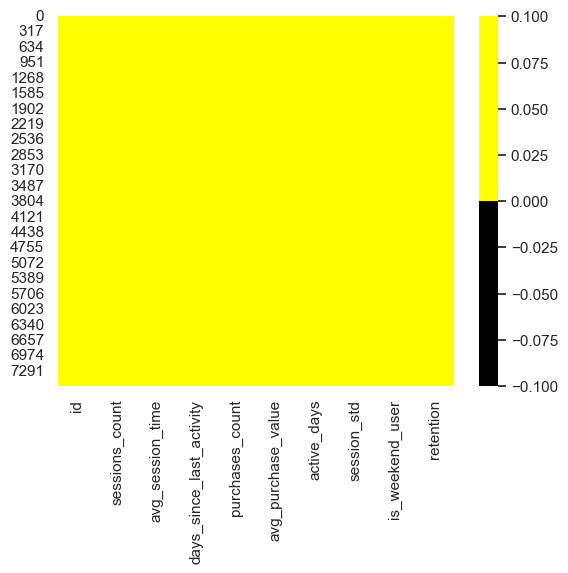

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention



 --- Проверка на Duplicates --- 


,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention



 === ЭТАП 2: Визуализация выбросов === 

 --- Визуализация выбросов (Числовые признаки) --- 


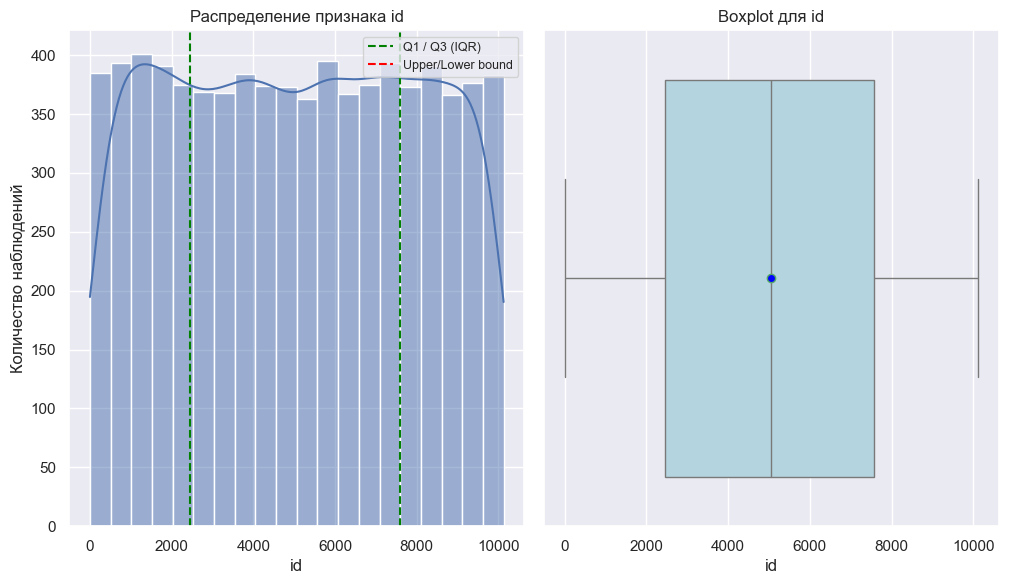

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention


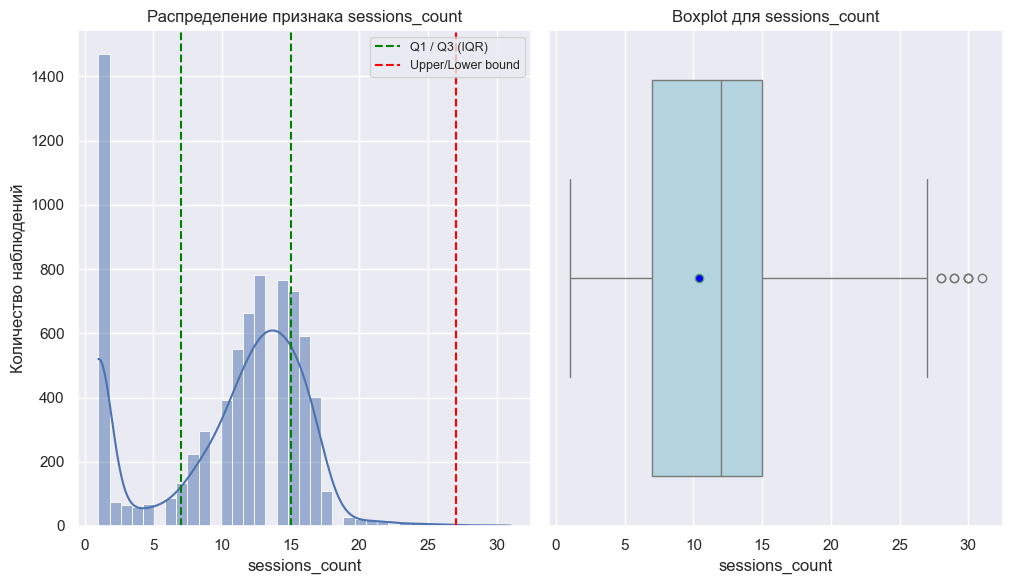

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
1441,1488,31,51.218663,22,14,7382.701290,19,13.029392,1,1
1475,2196,30,43.912519,23,9,6811.676555,19,12.236026,1,1
5602,3171,30,47.764929,10,12,8042.336747,23,7.639139,0,1
4954,1872,30,23.731409,17,12,4231.308273,15,11.218656,1,1
6918,9283,29,38.957243,8,13,5133.488931,17,10.859650,0,1
3417,3689,29,48.321277,20,10,6564.141370,16,14.662543,0,0
4666,6845,28,32.373726,37,11,4733.130145,16,13.806855,1,0
5531,3444,28,32.745981,18,12,4961.841245,17,16.019503,1,0


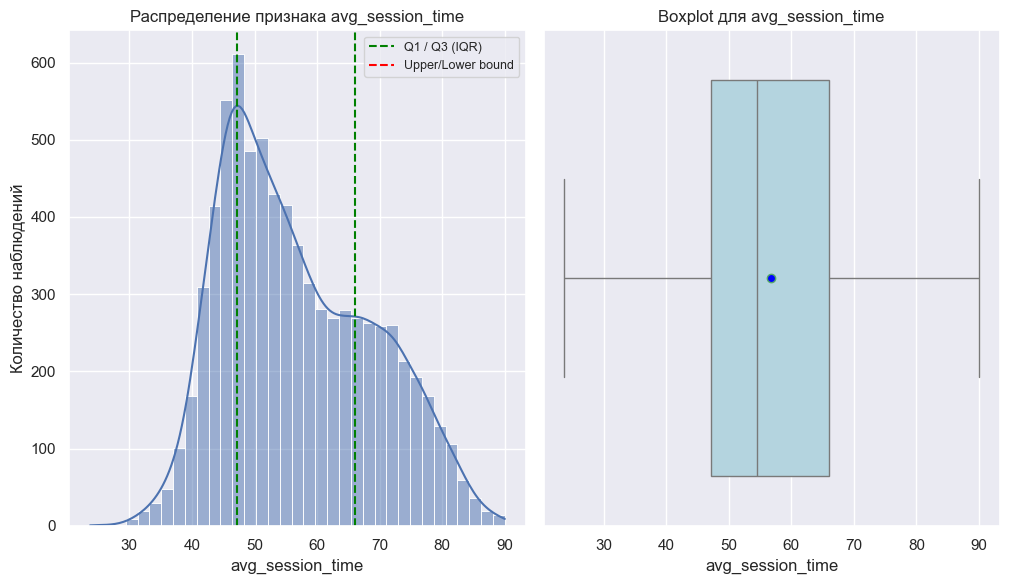

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention


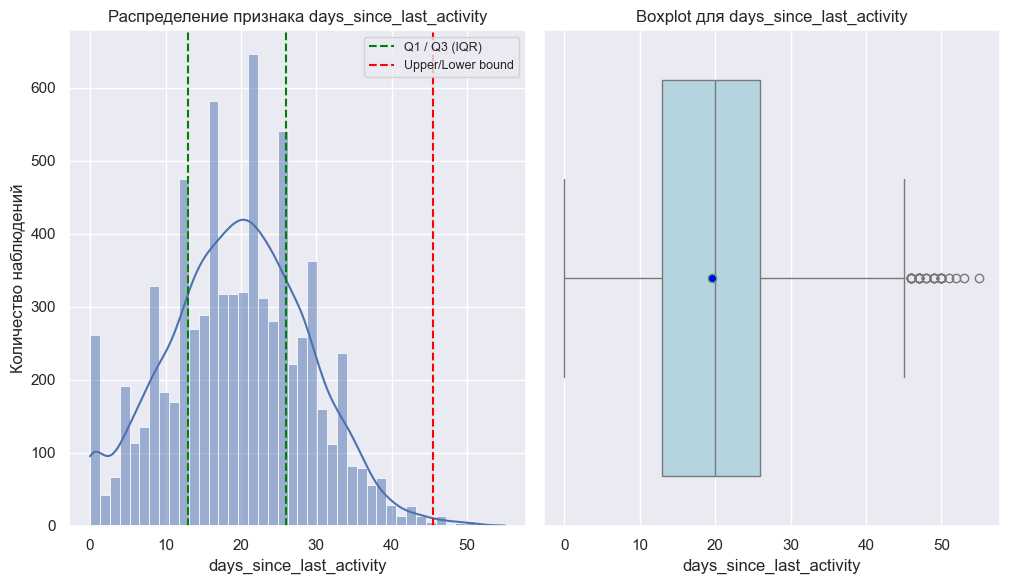

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
6359,9417,1,50.452619,55,9,4792.966325,30,3.184556,0,0
1071,1182,1,56.143269,53,10,5412.968145,29,0.704222,1,1
2000,7130,1,48.857754,52,9,5818.757065,16,8.389631,1,1
5753,612,1,53.494052,51,11,5442.799232,26,10.887881,0,1
2525,2821,11,55.819509,50,13,5413.895702,28,9.296420,1,0
3084,4193,1,47.605589,50,13,4644.391821,19,19.979329,1,0
1306,6355,1,47.148472,50,10,4551.035729,20,6.012609,1,0
7357,187,1,53.418184,50,8,4977.277050,29,15.846877,0,0
5718,5862,1,46.453372,50,11,4636.153839,18,6.810462,1,1
2122,8051,1,57.773627,50,10,5423.132081,30,14.175176,0,0


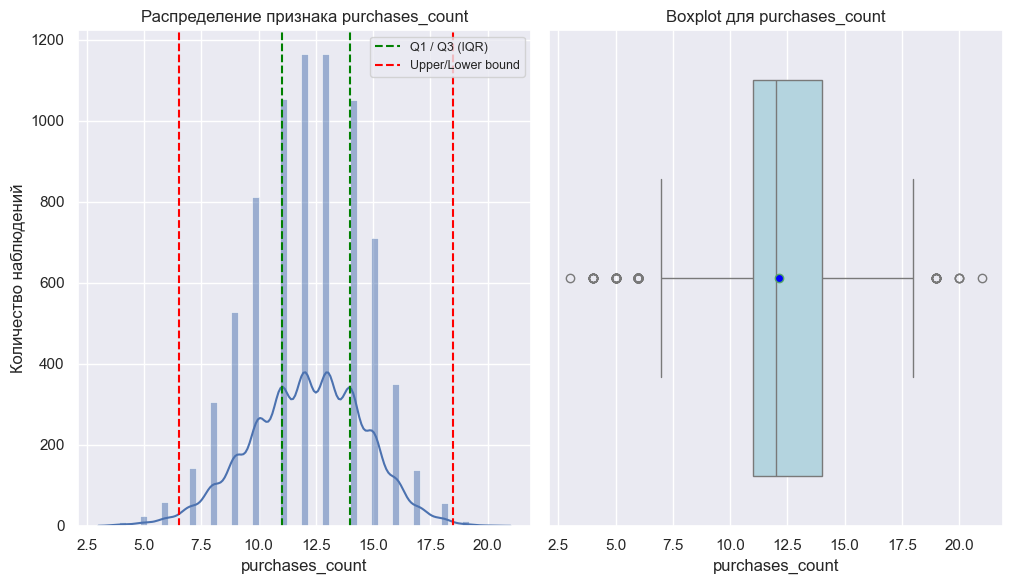

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
1613,8515,4,61.328791,16,21,6041.560824,26,13.885560,0,1
7539,5569,8,65.683361,17,20,5934.080673,18,14.722203,1,1
5391,9677,12,81.628985,16,20,8143.935159,19,13.574193,0,1
5335,7349,6,88.704986,6,20,7970.667131,24,19.355180,0,1
606,7968,1,63.508133,18,19,6105.907117,30,18.205345,1,1
...,...,...,...,...,...,...,...,...,...,...
5276,628,1,47.136261,9,4,3863.955655,14,10.073701,0,0
6186,828,2,50.067772,9,4,7358.809131,17,0.989328,0,1
5821,3473,4,39.994783,36,4,4129.147431,15,10.843186,0,1
7062,255,1,41.672958,15,4,4473.264437,16,10.139862,1,0


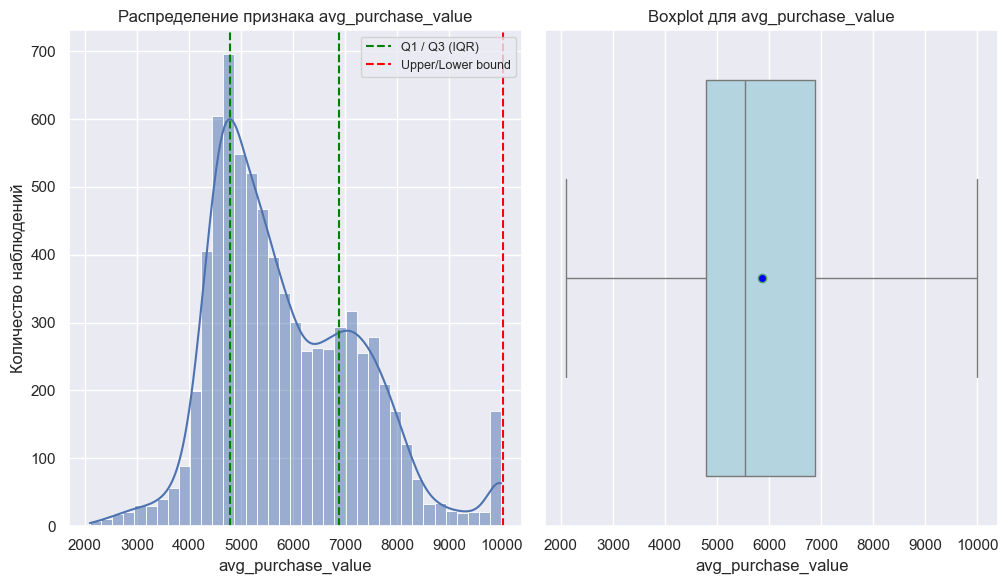

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention


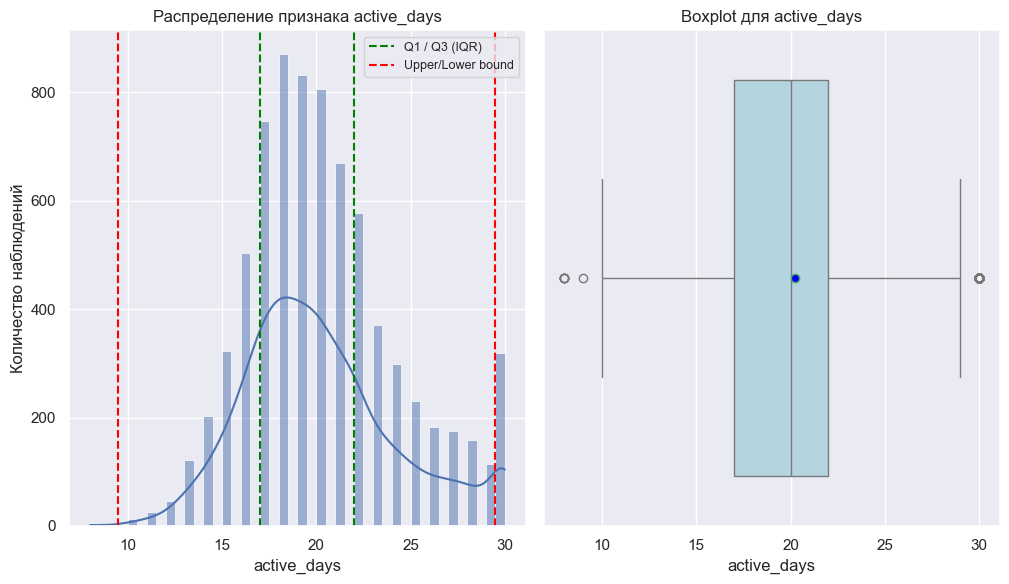

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
7588,7235,11,59.790327,15,12,6058.659656,30,5.491851,1,1
10,1885,11,45.980959,26,16,4809.961413,30,14.455592,0,1
28,4301,1,57.062342,19,11,5694.417189,30,13.144903,1,1
38,3747,9,55.075762,23,14,4811.789370,30,14.028606,1,0
94,7923,13,90.000000,40,13,8620.104626,30,7.630603,1,1
...,...,...,...,...,...,...,...,...,...,...
4708,2054,1,44.746001,18,14,5223.201870,8,15.771542,0,1
4846,3619,1,43.540707,33,5,4420.788486,8,0.520421,0,1
3881,2229,4,41.602949,29,7,4354.892395,8,20.073542,1,1
1110,191,18,32.285826,25,7,4111.664428,8,14.386531,1,0


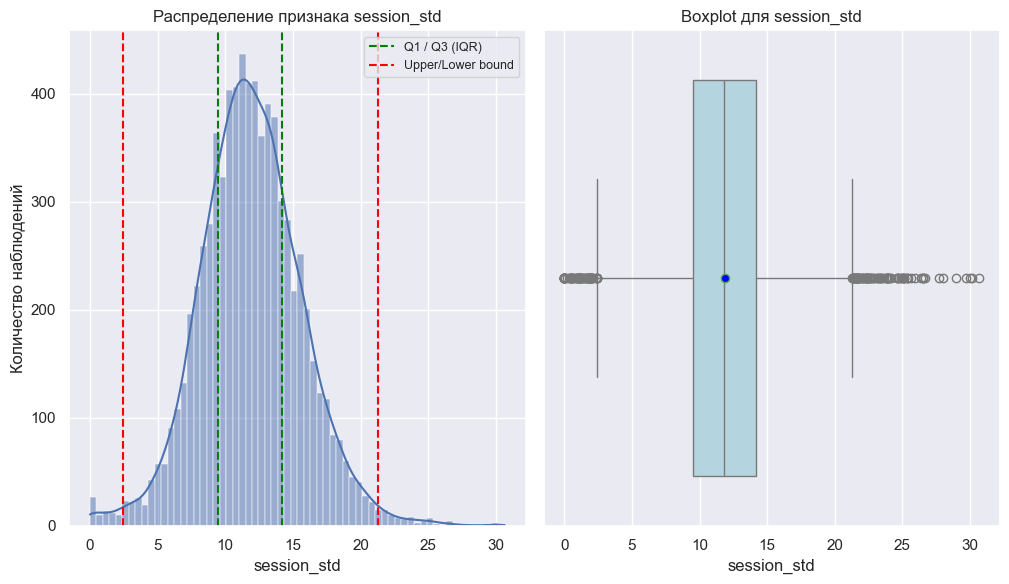

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
4831,10097,1,40.357545,16,14,4973.101311,24,30.661213,1,1
2049,756,1,43.342158,48,8,4499.269702,22,30.128520,1,0
2408,3422,1,45.203126,45,6,4502.143175,28,29.986537,0,0
863,2083,1,46.695669,20,12,4796.094030,10,29.724945,1,1
1267,5462,1,45.015847,12,8,4986.404946,14,28.991010,1,1
...,...,...,...,...,...,...,...,...,...,...
5443,9469,1,58.455549,17,8,5476.178609,22,0.000000,0,0
6304,2488,1,43.399304,33,8,4076.598452,15,0.000000,1,1
5860,5658,1,55.158291,24,11,5693.052351,30,0.000000,0,0
6977,3368,1,41.201941,13,8,4278.456921,17,0.000000,0,1



 --- Визуализация выбросов (Категориальные признаки) --- 

 --- Визуализация (Бинарные признаки) --- 


is_weekend_user
0    3802
1    3793
Name: count, dtype: int64

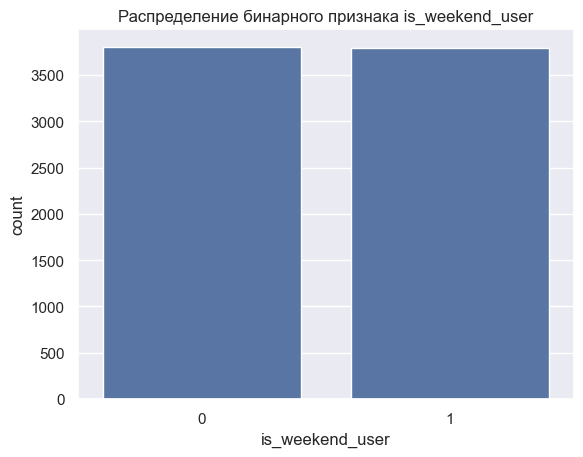

retention
1    5561
0    2034
Name: count, dtype: int64

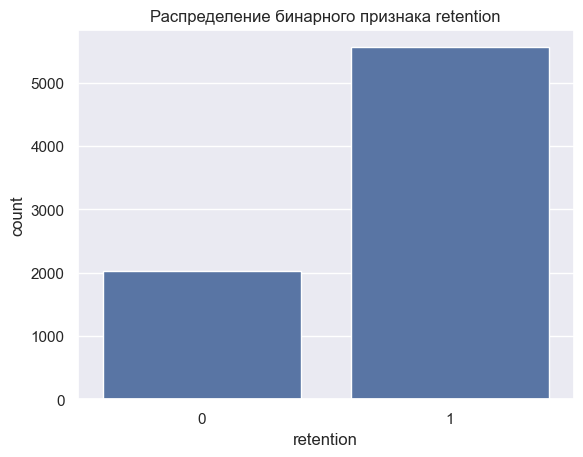

In [22]:
pipeline = DataPreprocessingPipeline(dataframe=train_df)
pipeline.start_pipeline()

### Решения по выбросам:
### В данных есть математические выбросы - парадоксы и логические несостыковки: данные по session_std != 0 при sessions_count = 1; количество sessions_count меньше, чем количество active_days; распределение значений внутри бинарного признака is_weekend_user почти 50/50, что невозможно для настоящих данных (5 рабочих дней и 2 выходных. Должен быть выраженный перекос значений в какую-то из сторон); Нельзя определить временной промежуток среза данных, так как сумма признаков days_since_last_activity и active_days не позволяет установить единый и логичный временной интервал наблюдения за выборкой; 
### В датасете много синтетических данных, поэтому стоит удалять только логические выбросы, которые не противоречат математическим (Можно удалить выбросы у признака sessions_count, так как они возможны, но имеют крайние значения)
### Нужно исследовать эти математические аномалии, глянув процент retention внутри этих парадоксов

In [41]:
# Удаляем крайние значения, которые не противоречат логике и математике
# Создадим специальную маску для этого
normal_ejections = (train_df["sessions_count"] >= 28) & (train_df["sessions_count"] <= 31)
train_df_clean = train_df[~normal_ejections]
display(train_df_clean.shape)

(7587, 10)

## Взаимосвязь между признаками/корреляция/анализ аномалий

### Анализ математических аномалий


In [45]:
# Выделяем строки с логическим парадоксом
df_paradox = train_df[train_df['sessions_count'] < train_df['active_days']]

# Смотрим на процентное соотношение классов в таргете
print(df_paradox['retention'].value_counts(normalize=True))

retention
1    0.736555
0    0.263445
Name: proportion, dtype: float64
